In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
#from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("../data/normalized-perchip-arcsinh.csv", index_col=0)
display(df)

,10000_at,10001_at,10002_i_at,10003_f_at,10004_at,10005_at,10006_at,10007_at,10008_at,10009_at,...,9990_at,9991_at,9992_at,9993_at,9994_at,9995_at,9996_at,9997_at,9998_at,9999_at
GSM77298,0.055339,1.437047,2.520894,3.803361,0.005650,1.533861,0.614774,1.918247,0.025986,0.309175,...,1.178673,0.079014,0.487771,1.266814,3.685886,1.585712,4.093568,2.347292,0.136301,2.288447
GSM77299,0.073751,1.351225,2.436446,3.097790,0.004614,1.398911,0.598074,2.038964,0.028831,0.088696,...,1.493072,0.118523,0.350344,1.754934,3.269344,1.169223,4.554970,2.056239,0.236542,2.491590
GSM77300,0.119759,0.997280,2.739272,3.679443,0.049810,1.594438,0.615066,1.982846,0.190243,0.166835,...,1.306491,0.071287,0.414943,1.427824,3.668934,1.362803,4.725811,2.231584,0.175764,2.492338
GSM77301,0.054967,0.980137,2.785481,3.553888,0.013468,1.369467,0.811451,2.034463,0.155379,0.084076,...,1.466488,0.127600,0.549871,1.665212,3.770282,1.160348,4.587313,1.850947,0.194066,2.309352
GSM77302,0.030197,0.836380,2.813253,3.535727,0.004474,1.315025,0.966502,1.860060,0.017896,0.190128,...,1.497345,0.086024,0.317885,0.773877,3.537029,1.138892,4.341968,1.980670,0.167008,2.127815
GSM77303,0.025971,0.826778,2.699219,3.599009,0.030298,1.373747,0.877542,1.933411,0.038951,0.156289,...,1.428039,0.081080,0.697471,1.633885,3.867119,1.058365,3.878191,1.560221,0.146660,1.962445
GSM77304,0.012973,0.761114,2.613701,3.659863,0.006486,1.291188,0.927984,1.706019,0.030266,0.272298,...,1.514344,0.112197,0.759455,1.711327,3.910779,1.252416,3.998844,1.744466,0.192326,2.030064
GSM77305,0.091349,0.924795,2.861251,3.866385,0.008316,1.445029,0.893814,1.654158,0.064405,0.346458,...,1.613508,0.118227,0.891627,1.706559,4.059844,1.288954,3.424599,1.738230,0.106865,1.868203
GSM77306,0.088157,1.883680,3.094087,4.604133,0.012092,1.871753,1.790942,1.022613,0.111017,0.405930,...,1.797983,0.102601,0.932581,0.364318,4.626182,1.495408,3.471977,2.144238,0.112219,1.859690
GSM77307,0.062599,1.270484,2.776888,4.196536,0.005593,1.409092,0.472189,1.372392,0.027961,0.277197,...,1.326730,0.077105,0.382131,1.045145,4.113193,1.650963,3.803873,1.540347,0.071527,2.008170


In [5]:
clusterdf = pd.read_csv("classical_ts__s__gmm_clustered__visible_signal.csv", index_col=0)
display(clusterdf)

,labels,probabilities
10001_at,7,0.857061
10003_f_at,3,0.999703
10005_at,3,0.997951
10010_at,5,0.986816
10011_at,7,0.701117
...,...,...
9992_at,0,0.993806
9994_at,3,0.998811
9996_at,2,0.966032
9998_at,2,0.993418


In [6]:
clustered_data = pd.merge(clusterdf.drop(columns=["probabilities"]), df.T, left_index=True, right_index=True)
display(clustered_data)

,labels,GSM77298,GSM77299,GSM77300,GSM77301,GSM77302,GSM77303,GSM77304,GSM77305,GSM77306,...,GSM77324,GSM77325,GSM77326,GSM77327,GSM77328,GSM77329,GSM77330,GSM77331,GSM77332,GSM77333
10001_at,7,1.437047,1.351225,0.997280,0.980137,0.836380,0.826778,0.761114,0.924795,1.883680,...,1.050237,0.891368,0.887193,0.774625,0.861921,1.970621,1.656134,1.573671,1.706939,1.803642
10003_f_at,3,3.803361,3.097790,3.679443,3.553888,3.535727,3.599009,3.659863,3.866385,4.604133,...,3.602857,3.440328,3.561384,3.630543,3.800901,4.394373,4.054006,3.730895,3.748445,3.772102
10005_at,3,1.533861,1.398911,1.594438,1.369467,1.315025,1.373747,1.291188,1.445029,1.871753,...,1.436538,1.329286,1.240209,1.348405,1.422917,1.809440,1.557465,1.561141,1.727630,1.768271
10010_at,5,4.087141,3.974576,4.162059,3.803687,3.442702,3.058513,3.396971,3.214069,3.307293,...,3.864080,3.533334,3.269016,3.457854,3.471743,3.349254,3.950183,3.751380,3.959832,3.969010
10011_at,7,0.260326,0.116232,0.169069,0.150941,0.148226,0.076764,0.161460,0.100662,0.176828,...,0.242805,0.116253,0.104962,0.120130,0.142685,0.144991,0.250119,0.190809,0.291229,0.370591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992_at,0,0.487771,0.350344,0.414943,0.549871,0.317885,0.697471,0.759455,0.891627,0.932581,...,0.511822,0.338963,0.600388,0.557117,0.506965,1.132667,0.591767,0.430282,0.448520,0.443950
9994_at,3,3.685886,3.269344,3.668934,3.770282,3.537029,3.867119,3.910779,4.059844,4.626182,...,3.773198,3.540522,3.811130,3.949760,3.339223,4.464466,4.264264,3.832299,3.940158,3.935605
9996_at,2,4.093568,4.554970,4.725811,4.587313,4.341968,3.878191,3.998844,3.424599,3.471977,...,4.547198,4.410960,4.309221,4.290862,3.983282,3.434828,4.060665,3.874688,3.990781,4.005935
9998_at,2,0.136301,0.236542,0.175764,0.194066,0.167008,0.146660,0.192326,0.106865,0.112219,...,0.195365,0.144381,0.139751,0.156429,0.140521,0.086206,0.092864,0.071438,0.078548,0.108259


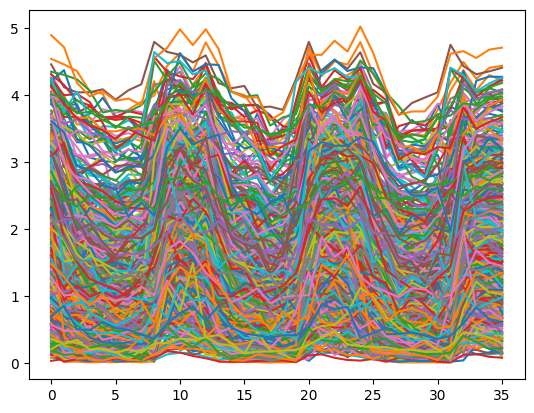

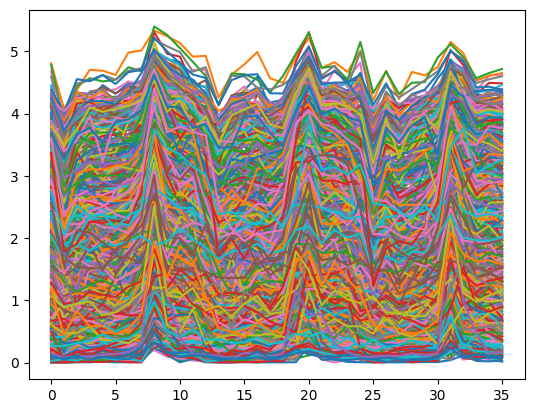

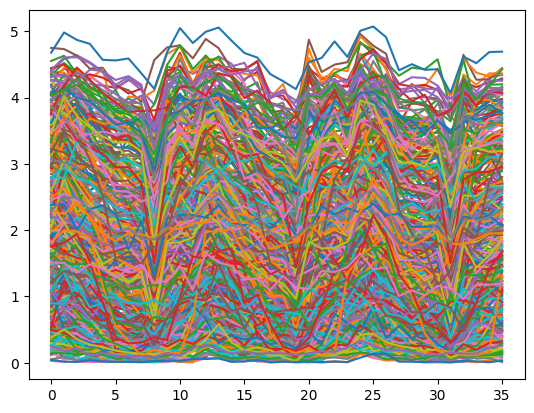

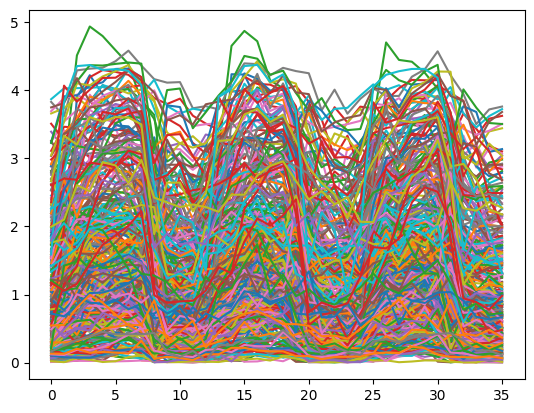

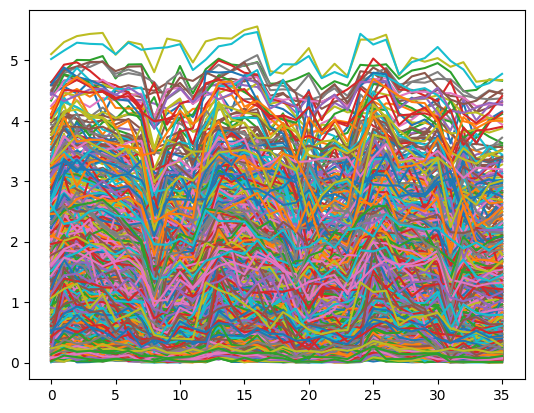

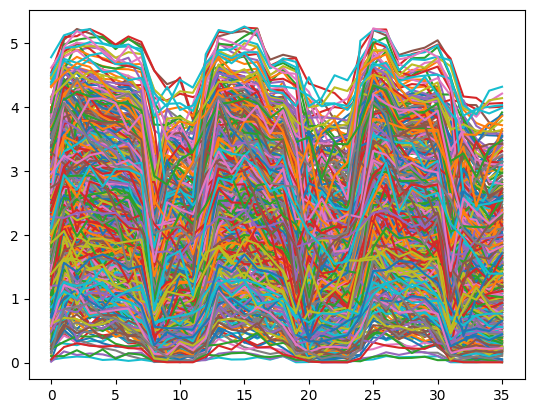

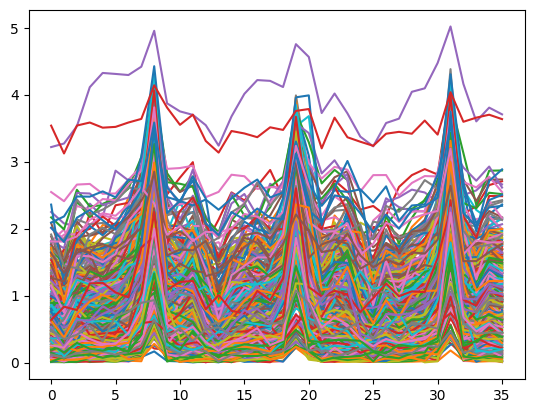

In [7]:
for cluster in clustered_data["labels"].unique():
    cluster_data = clustered_data[clustered_data["labels"] == cluster]
    data = cluster_data.drop(columns=["labels"])
    data = data.T.values
    plt.plot(np.arange(36), data)
    plt.show()

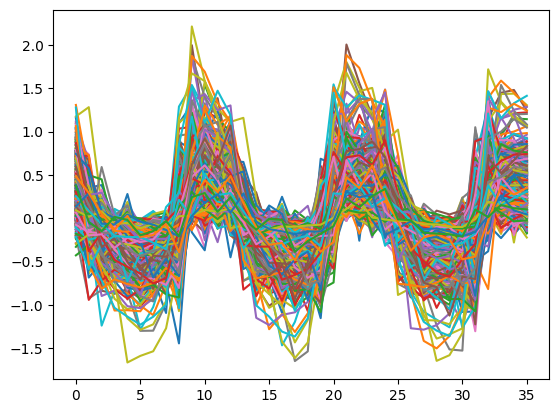

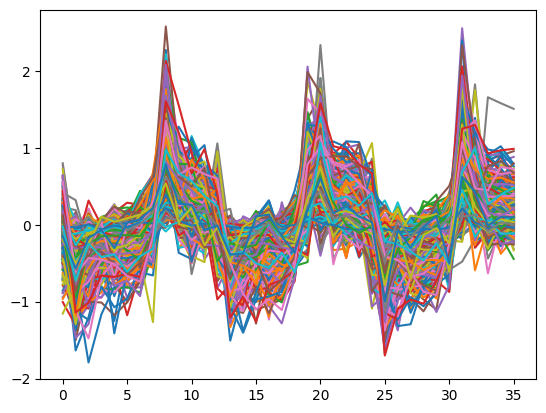

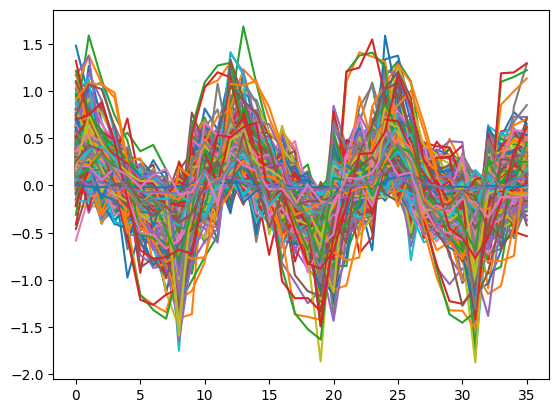

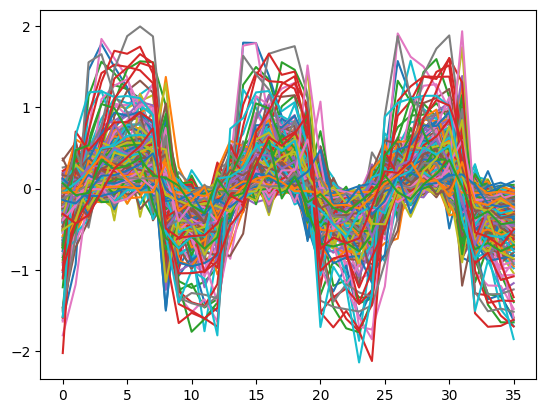

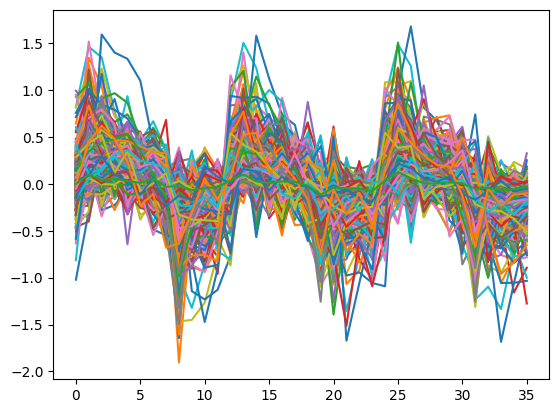

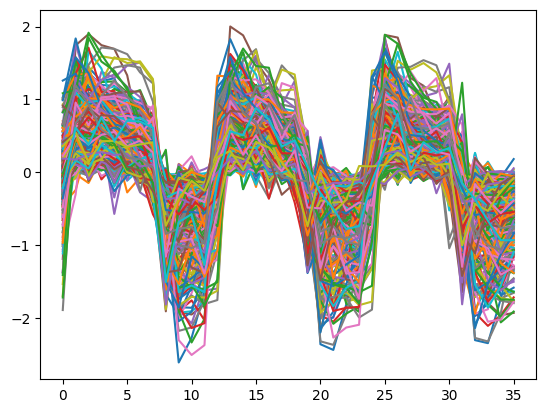

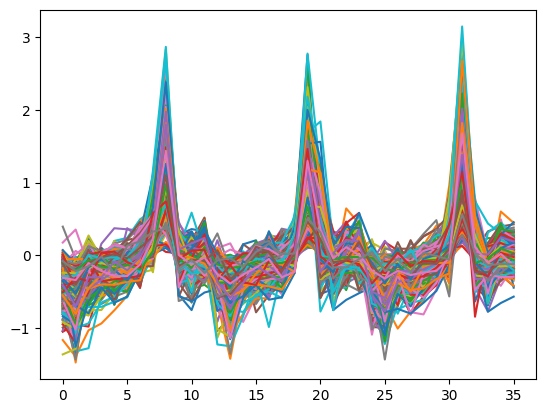

In [8]:
for cluster in clustered_data["labels"].unique():
    cluster_data = clustered_data[clustered_data["labels"] == cluster]
    data = cluster_data.drop(columns=["labels"])
    data = data.T.values
    data = data - data.mean(axis=0)
    plt.plot(np.arange(36), data)
    plt.show()

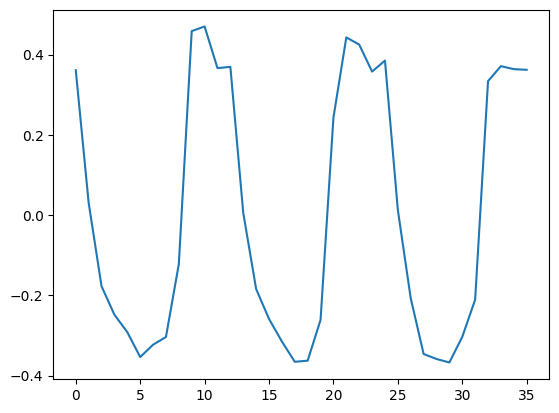

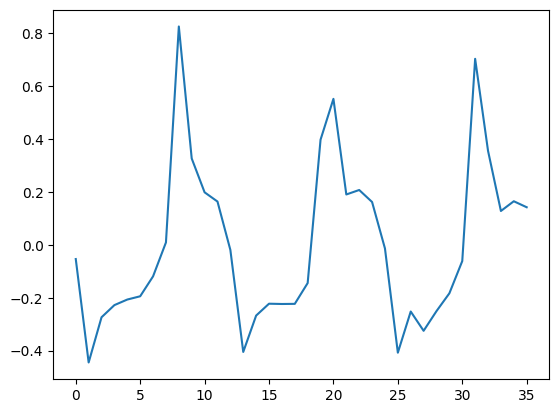

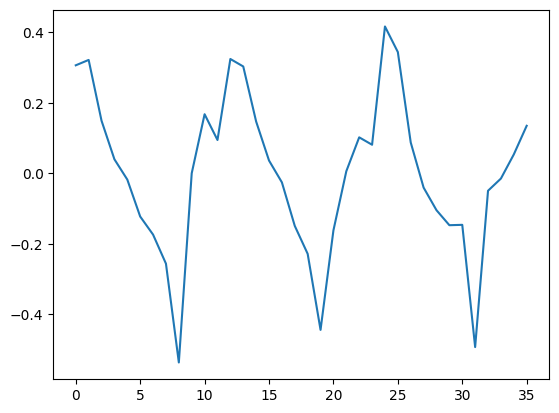

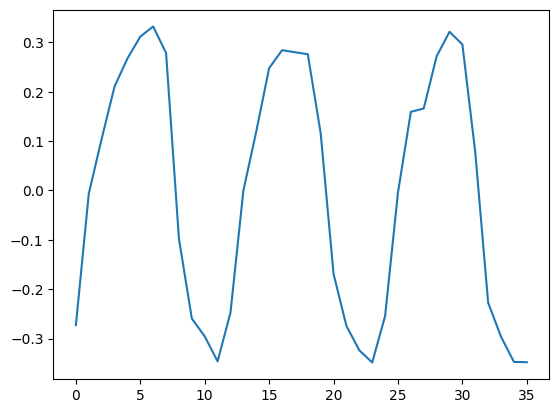

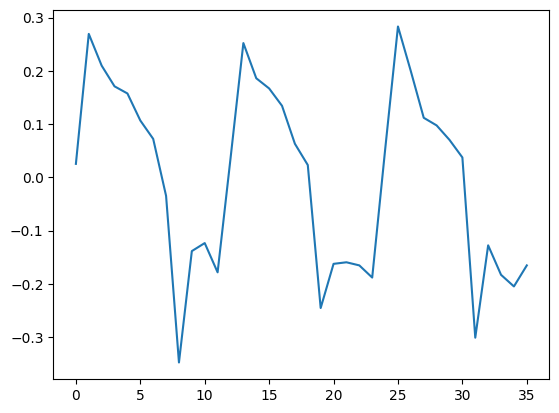

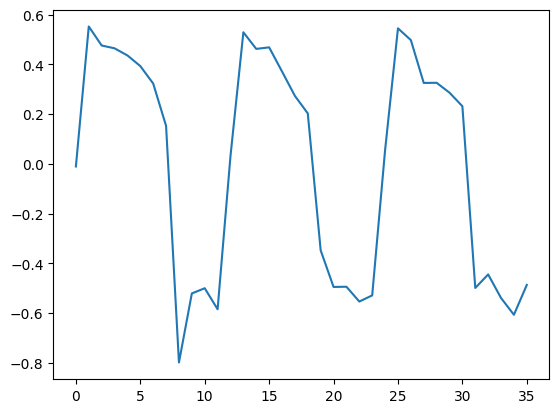

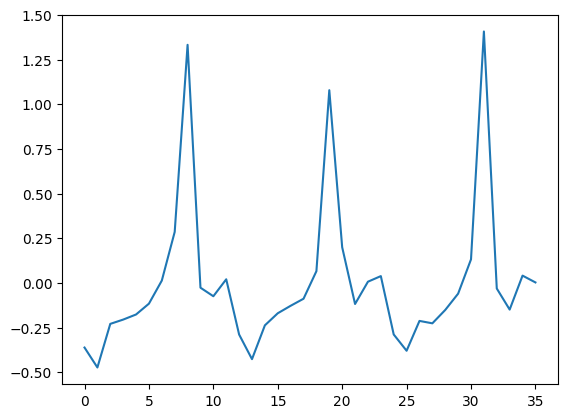

In [16]:
mean_clusters = {}
for cluster in clustered_data["labels"].unique():
    cluster_data = clustered_data[clustered_data["labels"] == cluster]
    data = cluster_data.drop(columns=["labels"])
    data = data.T.values
    data = data - data.mean(axis=0)
    mean_clusters[cluster] = data.mean(axis=1)
    plt.plot(np.arange(36), data.mean(axis=1))
    plt.show()

In [19]:
df = pd.DataFrame(mean_clusters)
df.to_csv('cluster_means.csv')

In [10]:
# this denoised data should now visualize nicely
Xraw = clustered_data.drop(columns=["labels"]).values
y = clustered_data["labels"]

In [11]:
display(Xraw.shape)

(3947, 36)

In [12]:
X = StandardScaler().fit_transform(Xraw.T).T

In [13]:
Xumap = UMAP().fit_transform(X)

NameError: name 'UMAP' is not defined

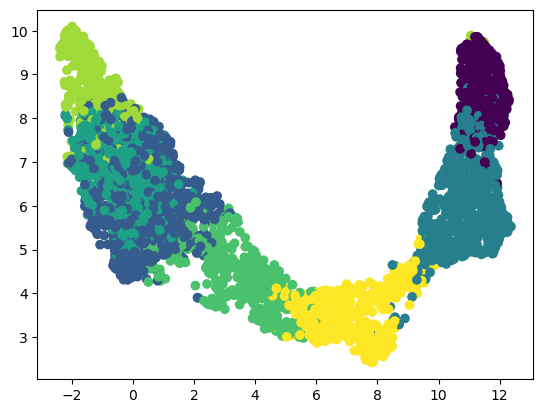

In [ ]:
plt.scatter(Xumap[:, 0], Xumap[:, 1], c=y)

In [ ]:
Xpca = PCA().fit_transform(X)

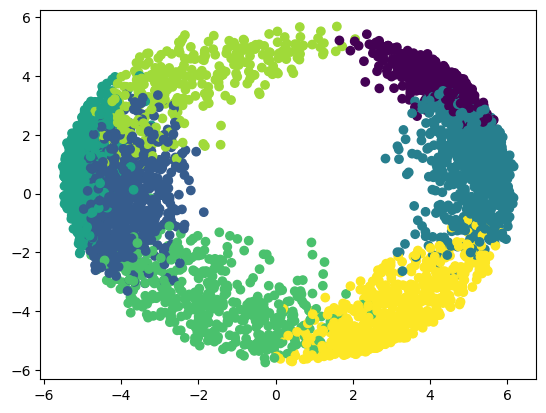

In [ ]:
plt.scatter(*Xpca[:,:2].T, c=y)

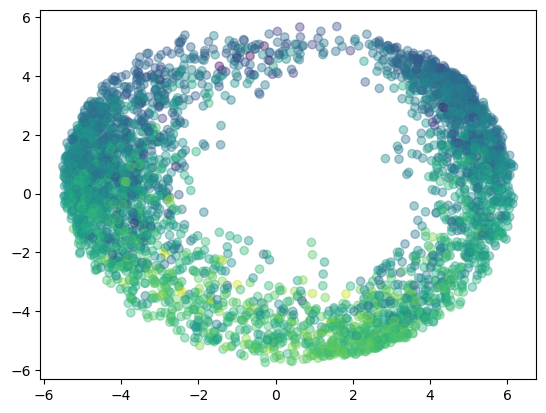

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ts = np.arange(36)

scatter = ax.scatter(*Xpca[:, :2].T, c=X[:, 0], cmap="viridis", alpha=0.4)

def update(t):
    scatter.set_array(X[:, t])

from matplotlib import animation
animation.writer = animation.writers["ffmpeg"]

ani = animation.FuncAnimation(fig, update, frames=ts, interval=1000 * 3 / 36)
ani.save("cleaned__relative_expression__pca.mp4")

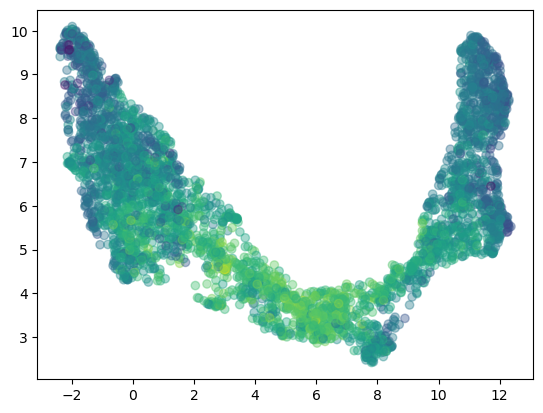

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ts = np.arange(36)

scatter = ax.scatter(*Xumap[:, :2].T, c=X[:, 0], cmap="viridis", alpha=0.4)

def update(t):
    scatter.set_array(X[:, t])

from matplotlib import animation
animation.writer = animation.writers["ffmpeg"]

ani = animation.FuncAnimation(fig, update, frames=ts, interval=1000 * 3 / 36)
ani.save("cleaned__relative_expression__umap.mp4")

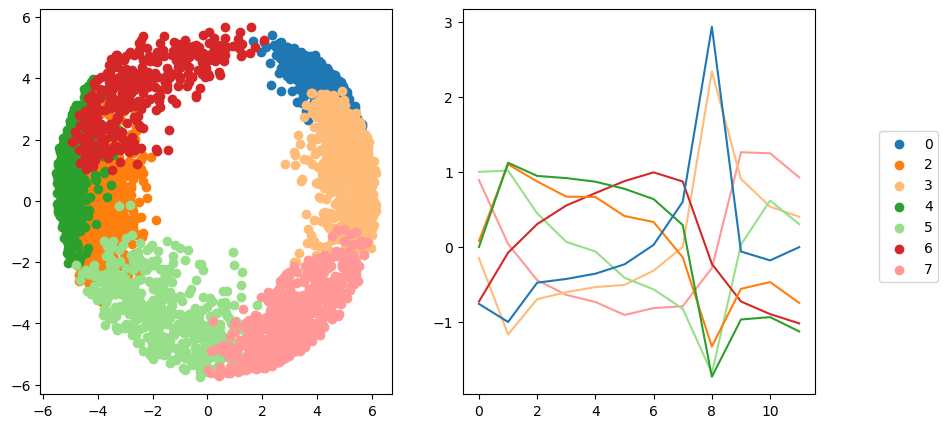

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as colors

# following AI on how to sync up these colormaps
categories = np.unique(y)
num_categories = len(categories)

cmap_name = 'tab20'
cmap = plt.colormaps[cmap_name]

# bounds = np.arange(num_categories + 1) - 0.5
# norm = colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for cluster in np.sort(y.unique()):
    ax[0].scatter(*Xpca[y == cluster,:2].T, color=cmap(cluster), label=cluster)

# mycolors = cmap(y)

for cluster in y.unique():
    Xclust = X[y == cluster]
    Xmean = Xclust.mean(axis=0)
    ax[1].plot(np.arange(12), Xmean[:12], c=cmap(cluster))

fig.legend(bbox_to_anchor=(1.03, 0.65))

In [ ]:
# get top 20 genes from each cluster in terms of probability - they will probably be the most central or potentially most extreme genes of the clusters

At this point I think the big next step is to take these clusters and figure out what they are. Time to join with the metadata frame and figure out what they are.